**[🏠 Course Home](00_START_HERE.ipynb) | 📖 Conceptual Companion: [Appendix E: Framework Reliability](../conceptual/appendix_e_framework_reliability_and_tolerance_contracts.ipynb) | 🔵 R Companion: [Appendix E: Framework Reliability](../r/appendix_framework_reliability_and_tolerance_contracts.ipynb) | ↩️ Return to: [Appendix: Tolerance Intervals](appendix_frequentist_vs_bayesian_tolerance_intervals.ipynb)**

---

# 🐍 Appendix: Framework Reliability & Tolerable Flakiness — The Two-Tier Tolerance Contract
### *Serial Compounding, The Plug-In Fallacy, and Qualifying Test Harnesses under Real Uncertainty*

In **[Appendix: Tolerance Intervals](appendix_frequentist_vs_bayesian_tolerance_intervals.ipynb)**, we explored tolerance intervals for continuous variables (server latency headroom). In this companion appendix, we apply Bayesian tolerance guarantees to **discrete serial reliability pipelines**: specifically, how to specify and qualify the tolerable flakiness of foundational testing frameworks.

---

## Table of Contents
1. **Part 1: The Serial Multiplier (The Math of Suite Collapse)**
2. **Part 2: The Two Traps (Flaw of Averages & Plug-In Fallacy)**
3. **Part 3: The Bayesian Posterior Predictive Engine**
4. **Part 4: Production Qualification via Stress Injection & Wald's SPRT**
5. **Part 5: Business Economics & False Discovery Rate (FDR)**
6. **Part 6: Implementation Checklist & Architecture Contract Template**

---

## Part 1: The Serial Multiplier (The Math of Suite Collapse)

A test suite is a serial reliability system. If a PR runs $K$ tests and each invocation has framework flakiness probability $\theta$, suite survival is:

$$R_{\text{suite}} = (1 - \theta)^K \approx e^{-K\theta}$$

Let us simulate and visualize suite survival across realistic suite sizes ($K = 50$ to $3{,}000$) and various framework flake rates.

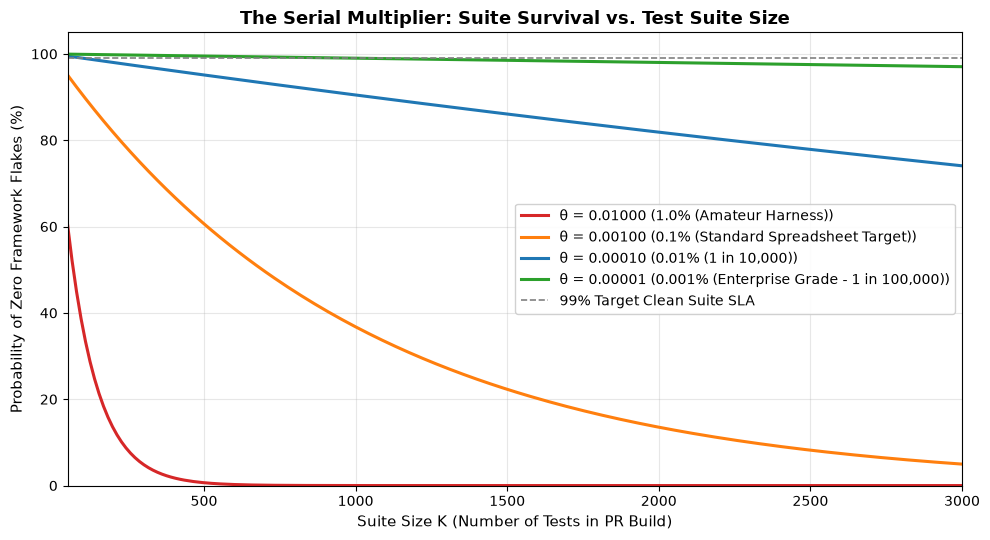

=== Suite-Level Survival at K = 1,000 Tests ===
θ = 0.01000 -> Suite Survival =   0.00% | Expected Framework Red Builds = 100.00%
θ = 0.00100 -> Suite Survival =  36.77% | Expected Framework Red Builds =  63.23%
θ = 0.00010 -> Suite Survival =  90.48% | Expected Framework Red Builds =   9.52%
θ = 0.00001 -> Suite Survival =  99.00% | Expected Framework Red Builds =   1.00%


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Vectorized simulation across suite sizes K and framework failure rates theta
K_values = np.linspace(50, 3000, 200)
flake_rates = [
    (0.01, '1.0% (Amateur Harness)', 'tab:red'),
    (0.001, '0.1% (Standard Spreadsheet Target)', 'tab:orange'),
    (0.0001, '0.01% (1 in 10,000)', 'tab:blue'),
    (0.00001, '0.001% (Enterprise Grade - 1 in 100,000)', 'tab:green'),
]

plt.figure(figsize=(10, 5.5))
for theta, label, color in flake_rates:
    R_suite = (1 - theta) ** K_values
    plt.plot(K_values, R_suite * 100, label=f"θ = {theta:.5f} ({label})", color=color, lw=2.2)

plt.axhline(99.0, color='gray', ls='--', lw=1.2, label='99% Target Clean Suite SLA')
plt.title("The Serial Multiplier: Suite Survival vs. Test Suite Size", fontsize=13, fontweight='bold')
plt.xlabel("Suite Size K (Number of Tests in PR Build)", fontsize=11)
plt.ylabel("Probability of Zero Framework Flakes (%)", fontsize=11)
plt.ylim(0, 105)
plt.xlim(50, 3000)
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

print("=== Suite-Level Survival at K = 1,000 Tests ===")
for theta, label, _ in flake_rates:
    r = (1 - theta) ** 1000
    print(f"θ = {theta:.5f} -> Suite Survival = {r*100:6.2f}% | Expected Framework Red Builds = {(1-r)*100:6.2f}%")

## Part 2: The Two-Tier Posterior Predictive Engine

To qualify a framework without committing the plug-in fallacy, we evaluate both tiers under parameter uncertainty:
1. **Tier 1 (Suite-Level Guarantee)**: $\mathbb{P}(\tilde{Y}_{\text{flakes}} = 0 \text{ in } K \text{ tests} \mid \mathcal{D}) \ge 99.0\%$
2. **Tier 2 (Per-Invocation Tolerance Bound)**: $\mathbb{P}(\theta \le 1.0 \times 10^{-5} \mid \mathcal{D}) \ge 95.0\%$

In [2]:
def evaluate_framework_qualification(n_benchmarks, k_failures, K_suite_size=1000, n_sims=100_000, alpha_prior=1, beta_prior=1):
    """
    Evaluates whether benchmark telemetry satisfies the 2-Tier Framework SLA:
    1. P(Clean Suite of K tests | Data) >= 99%
    2. P(theta <= 1e-5 | Data) >= 95%
    """
    # 1. Posterior draws for theta
    a_post = alpha_prior + k_failures
    b_post = beta_prior + n_benchmarks - k_failures
    theta_draws = stats.beta.rvs(a_post, b_post, size=n_sims)
    
    # 2. Tier 2: Parameter tolerance bound P(theta <= 1e-5)
    p_theta_sub_1e5 = np.mean(theta_draws <= 1e-5)
    
    # 3. Tier 1: Suite-level posterior predictive simulation
    suite_flakes = stats.binom.rvs(n=K_suite_size, p=theta_draws)
    p_clean_suite = np.mean(suite_flakes == 0)
    
    # 95% Credible Interval on theta
    q025, q50, q975 = np.percentile(theta_draws, [2.5, 50, 97.5])
    
    return {
        'n_benchmarks': n_benchmarks,
        'k_failures': k_failures,
        'theta_median': q50,
        'theta_95_hdi': (q025, q975),
        'p_theta_sub_1e5': p_theta_sub_1e5,
        'p_clean_suite': p_clean_suite,
        'tier1_pass': p_clean_suite >= 0.99,
        'tier2_pass': p_theta_sub_1e5 >= 0.95
    }

# Test 4 benchmark scenarios
scenarios = [
    (500, 0, "Small Benchmark (500 runs, 0 flakes)"),
    (5_000, 0, "Medium Benchmark (5,000 runs, 0 flakes)"),
    (100_000, 0, "Rigorous Benchmark (100,000 runs, 0 flakes)"),
    (100_000, 1, "Realistic Scale (100,000 runs, 1 flake)"),
]

print(f"{'Scenario':<42} | {'P(Clean Suite >= 99%)':<22} | {'Tier 1':<7} | {'P(θ <= 1e-5)':<15} | {'Tier 2'}")
print("-" * 105)
for n, k, desc in scenarios:
    res = evaluate_framework_qualification(n, k, K_suite_size=1000)
    t1 = "PASS" if res['tier1_pass'] else "FAIL"
    t2 = "PASS" if res['tier2_pass'] else "FAIL"
    print(f"{desc:<42} | {res['p_clean_suite']*100:6.2f}% (Target: >=99%) | {t1:<7} | {res['p_theta_sub_1e5']*100:6.2f}%          | {t2}")

Scenario                                   | P(Clean Suite >= 99%)  | Tier 1  | P(θ <= 1e-5)    | Tier 2
---------------------------------------------------------------------------------------------------------
Small Benchmark (500 runs, 0 flakes)       |  33.51% (Target: >=99%) | FAIL    |   0.50%          | FAIL
Medium Benchmark (5,000 runs, 0 flakes)    |  83.47% (Target: >=99%) | FAIL    |   4.88%          | FAIL
Rigorous Benchmark (100,000 runs, 0 flakes) |  99.00% (Target: >=99%) | PASS    |  63.31%          | FAIL
Realistic Scale (100,000 runs, 1 flake)    |  97.92% (Target: >=99%) | FAIL    |  26.43%          | FAIL


## Part 3: Qualification via Stress Injection & Wald's SPRT

Under synthetic stress (CPU throttling, 150ms network jitter), latent race conditions amplify from $\theta_{\text{idle}} \approx 0.001\%$ to $\theta_{\text{stress}} \approx 3\%-5\%$.
We run Wald's Sequential Probability Ratio Test (SPRT) with dynamic early-abort.

In [3]:
# Wald's Sequential Probability Ratio Test (SPRT) under stress
theta_0 = 0.001  # H0: Clean under stress (<= 0.1%)
theta_1 = 0.05   # H1: Flaky under stress (>= 5.0%)
alpha_risk = 0.01
beta_risk = 0.01

A_threshold = np.log((1 - beta_risk) / alpha_risk)  # Reject H0 (Admit framework is flaky)
B_threshold = np.log(beta_risk / (1 - alpha_risk))  # Accept H0 (Certify framework is clean)

np.random.seed(42)
true_stress_rate = 0.04  # A subtle race condition exposed by stress

log_llr = 0.0
step = 0
llr_history = []

while log_llr < A_threshold and log_llr > B_threshold and step < 200:
    step += 1
    outcome = 1 if np.random.rand() < true_stress_rate else 0
    llr_step = np.log(theta_1 / theta_0) if outcome == 1 else np.log((1 - theta_1) / (1 - theta_0))
    log_llr += llr_step
    llr_history.append(log_llr)

print(f"SPRT Result under Stress: Evaluated in {step} test runs!")
if log_llr >= A_threshold:
    print(f"❌ REJECTED at run {step}: Flakiness detected! Saved >99% of benchmark compute.")
elif log_llr <= B_threshold:
    print(f"✅ CERTIFIED at run {step}: Passed stress criteria!")

SPRT Result under Stress: Evaluated in 43 test runs!
❌ REJECTED at run 43: Flakiness detected! Saved >99% of benchmark compute.


## Part 4: Business Economics & False Discovery Rate (FDR)

Let us compute the False Discovery Rate (FDR) as a function of the true application bug rate ($P(\text{Bug})$) and the framework false-red build rate ($P(\text{Flake})$).

In [4]:
def calculate_fdr(p_true_bug, p_framework_red):
    fdr = p_framework_red / (p_true_bug + p_framework_red)
    return fdr

p_bug = 0.02  # 2% of PRs have genuine application code regressions
for theta in [0.001, 0.0001, 0.00001]:
    r_suite = (1 - theta) ** 1000
    p_flake_red = 1 - r_suite
    fdr = calculate_fdr(p_bug, p_flake_red)
    print(f"θ = {theta:.5f} -> Framework False-Red = {p_flake_red*100:5.2f}% | FDR = {fdr*100:5.2f}% of failed builds are lies!")

θ = 0.00100 -> Framework False-Red = 63.23% | FDR = 96.93% of failed builds are lies!
θ = 0.00010 -> Framework False-Red =  9.52% | FDR = 82.63% of failed builds are lies!
θ = 0.00001 -> Framework False-Red =  1.00% | FDR = 33.22% of failed builds are lies!


## Summary & Contract Checklist

| Component | Target Spec | Implementation |
| :--- | :--- | :--- |
| **Tier 1 (SLA)** | $\mathbb{P}(\tilde{Y} = 0) \ge 99.0\%$ across $K = 1{,}000$ | Put in developer RFCs; defines the user experience. |
| **Tier 2 (Acceptance)** | $\mathbb{P}(\theta \le 1.0 \times 10^{-5}) \ge 95.0\%$ | Put in CI benchmark assertions; defines the test bar. |
| **Qualification** | Shake Table (CPU/jitter injection) + SPRT | Qualifies framework in $< 200$ runs instead of $100{,}000$ runs. |

---

**[🏠 Course Home](00_START_HERE.ipynb) | 📖 Conceptual Companion: [Appendix E: Framework Reliability](../conceptual/appendix_e_framework_reliability_and_tolerance_contracts.ipynb) | 🔵 R Companion: [Appendix E: Framework Reliability](../r/appendix_framework_reliability_and_tolerance_contracts.ipynb) | ↩️ Return to: [Appendix: Tolerance Intervals](appendix_frequentist_vs_bayesian_tolerance_intervals.ipynb)**